# Initiation au clustering

## Definition

Le clustering est une tâche **d'apprentissage non supervisée** consistant à constituer à partir des données des groupes (*clusters*) au sein duquel les  observations sont les plus similaires possibles et les plus éloignées possibles entre groupes différents

## [Tour d'horizon de différents algorithmes de clustering](https://sklearn.org/modules/clustering.html#overview-of-clustering-methods)

### L'algorithme [K-Means](https://scikit-learn.org/stable/modules/clustering.html#k-means)

#### Démo sur le fameux jeu de données iris

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.model_selection import GridSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
rawdata = load_iris()

In [ ]:
rawdata.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

On charge le data set dans un data frame:

In [ ]:
X = pd.DataFrame(rawdata['data'],columns=rawdata['feature_names'])
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y = pd.Series(rawdata['target'])

## Commençons par explorer les données

On regroupe les features et la cible pour plus de clarté dans la visualisation de données avec seaborn:

In [ ]:
df = X.copy()
df['target'] = y

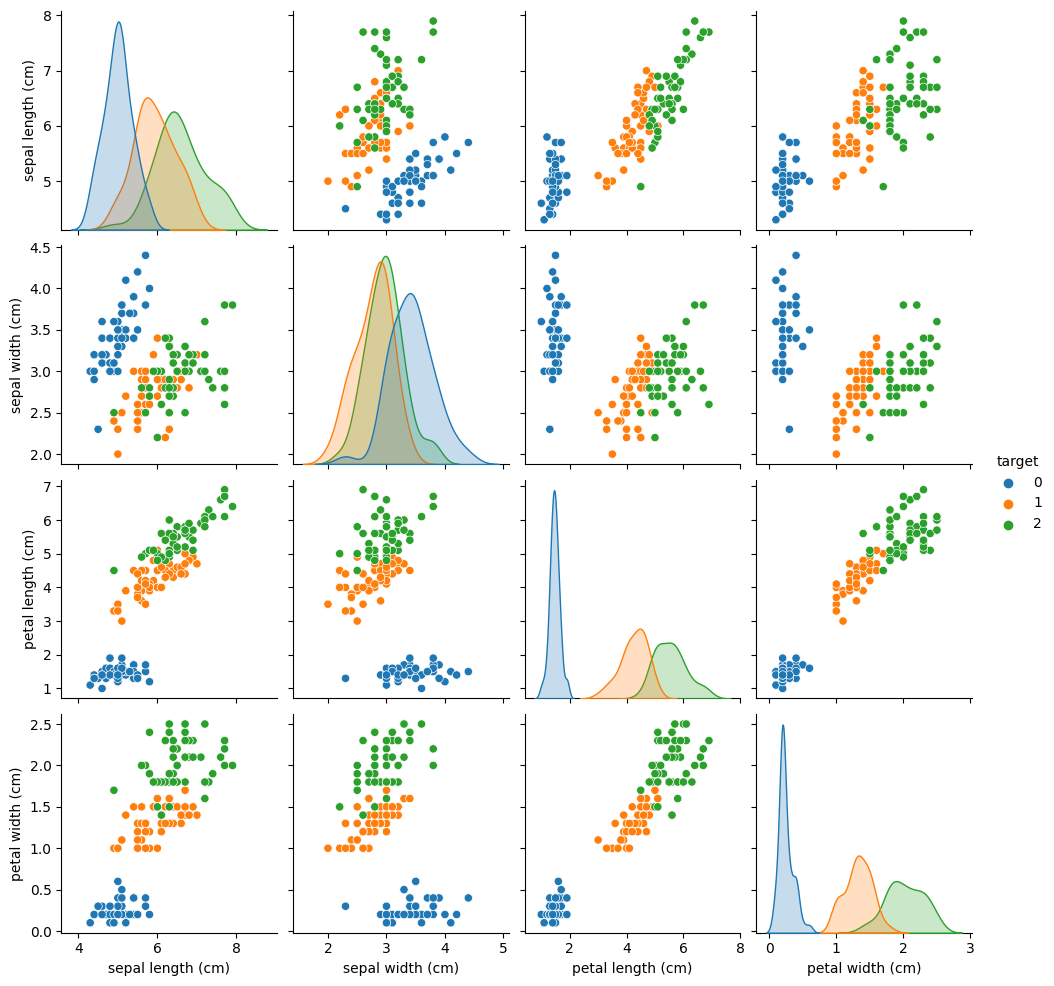

In [ ]:
sns.pairplot(df, hue='target',palette=sns.color_palette("tab10", 3));

Bien qu'on connaisse à l'avance dans ce dataset le nombre de groupes à créer (le nombre de classe de la variable target), on distingue assez facilement sur ce graphe 3 groupes distincts que l'on va essayer de séparer avec nos algorithmes de clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, algorithm = 'full')

In [ ]:
df['predicted_target'] = kmeans.fit_predict(X)

La métrique par défaut est l'inertie des clusters:

In [ ]:
kmeans.inertia_

78.851441426146

Comme on connait dans cet exemple les vraies classes, on peut calculer une autre métrique de clustering, par exemple, l'[Information Mutuelle Ajustée](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score).

Cette métrique renvoie un score compris entre 0 (pour deux partition assignée dont on aurait assigné les labels au hasard) et 1 pour deux partitions parfaitement identiques

In [ ]:
adjusted_mutual_info_score(df['target'],df['predicted_target'])

0.7551191675800482

Sans surprise, on obtient un score plutôt bon. Regardons la matrice de contingence pour comparer labels prédits et vrai labels:

In [ ]:
cm = contingency_matrix(df['target'],df['predicted_target'])
cm

array([[ 0, 50,  0],
       [48,  0,  2],
       [14,  0, 36]])

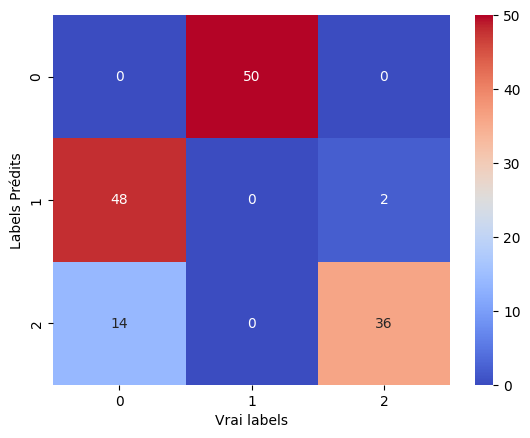

In [ ]:
ax = sns.heatmap(cm, annot=True, cmap ='coolwarm');
ax.set_xlabel("Vrai labels");
ax.set_ylabel("Labels Prédits");

**On peut remarquer que notre les labels prédits pour le cluster 1 en particulier sont assez souvent faux car intervertis avec le cluster 0 !**

Vérifions le en regardant de nouveau le pairplot:

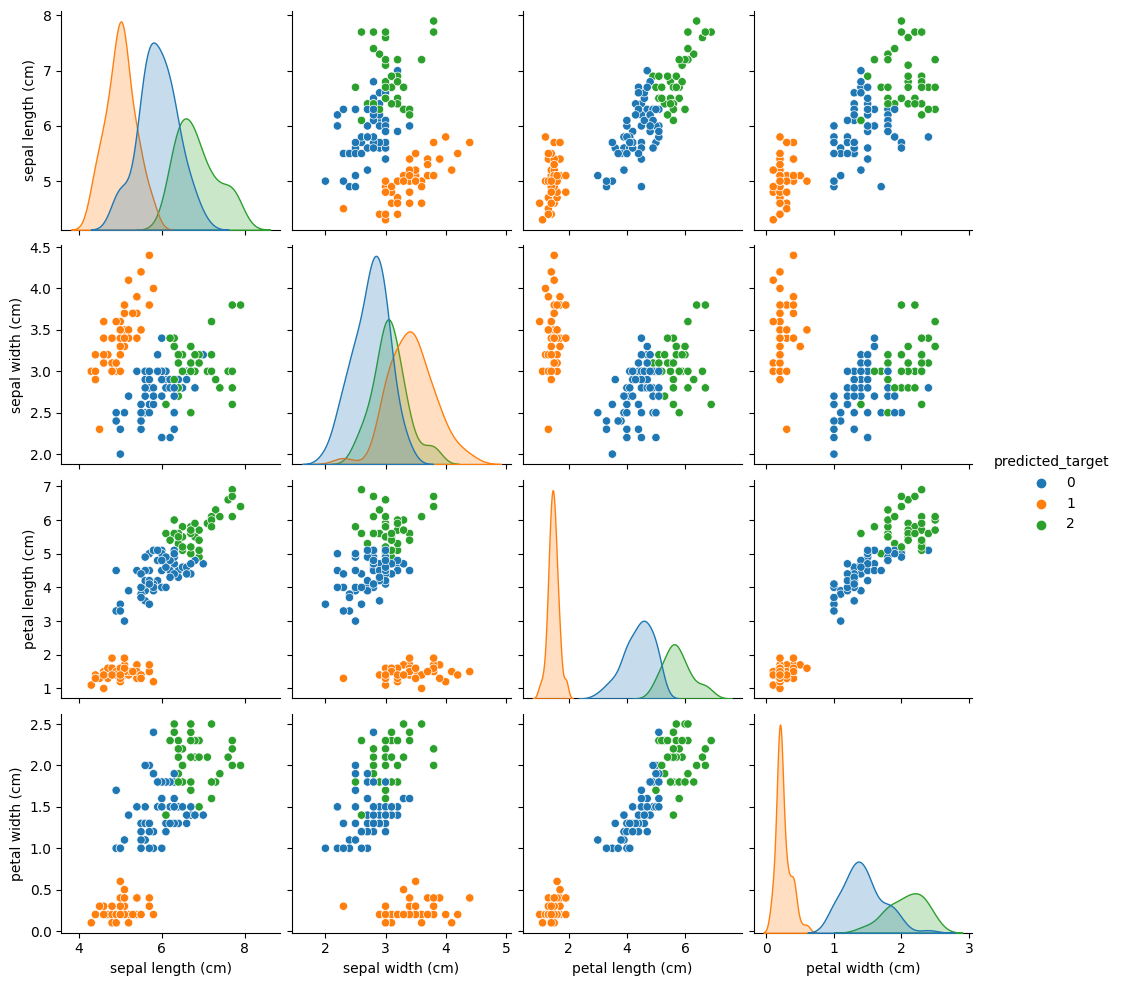

In [ ]:
sns.pairplot(df.drop(columns=['target']), hue='predicted_target', palette=sns.color_palette("tab10", 3))

Ici nous sommes dans un cas simpliste, car nous connaissions (et nous avons pu deviner) le nombre de clusters à priori. Voyons maintenant comme optimiser notre algorithmes en faisant varier cet hyper-paramètre:

In [ ]:
parameters = {"n_clusters":[2,3,4,5,6,7,8], "init":('random','k-means++'),\
               "algorithm":('elkan', 'full')}


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2, random_state=42)

In [ ]:
kmeans = KMeans(random_state = 42)
optimizer = GridSearchCV(kmeans, parameters).fit(X_train)

In [ ]:
optimizer.best_params_

{'algorithm': 'full', 'init': 'k-means++', 'n_clusters': 8}

En augmentant le nombre de clusters maximums, on se rend compte que le GridSearch nous renvoie toujours ce nombre comme meilleur paramètre.
Ca n'est pas étonnant car la plupart des métriques cherchent à minimiser la variance entre les clusters formés et seront donc toujours minimales pour le nombre maximum de clusters spécifié dans le GridSearch.

Il y a un **compromis** a trouver entre la **minimisation du score** et le **nombre clusters réels**. On va utiliser deux méthodes courantes pour déterminer ce compromis, la *méthode du coude* et une méthode basée sur la métrique du [score de silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn-metrics-silhouette-score):

In [ ]:
class Clusters():
    """Class for finding and ploting the tradeoff number of clusters for k-Means
    """
    def find_clusters_nb(self, method, kmeans_kwargs, kmax, kmin=2):
        self.kmax = kmax
        self.kmin = kmin
        self.method = method
        self.metric = []
        if self.method == 'elbow': 
            self.metric_name = "Inertia"
            for k in range(self.kmin, self.kmax+1):
                kmeans = KMeans(n_clusters=k, **kmeans_kwargs).fit(X)
                self.metric.append(kmeans.inertia_)
            return self.metric

        if self.method == 'silhouette': 
            self.metric_name = "Silhouette Coefficient"
            for k in range(self.kmin, self.kmax+1):
                kmeans = KMeans(n_clusters=k, **kmeans_kwargs).fit(X)
                self.metric.append(silhouette_score(X,kmeans.labels_))
            return self.metric
            
    def plot_metric(self):
        plt.style.use("seaborn")
        plt.plot(range(self.kmin,self.kmax+1), self.metric)
        plt.xticks(range(self.kmin,self.kmax+1))
        plt.xlabel("Number of clusters")
        plt.ylabel(f"{self.metric_name}")
        plt.title(f"Search for best k with {self.method} method")
        plt.show()        

In [ ]:
c = Clusters()

Méthode du coude:

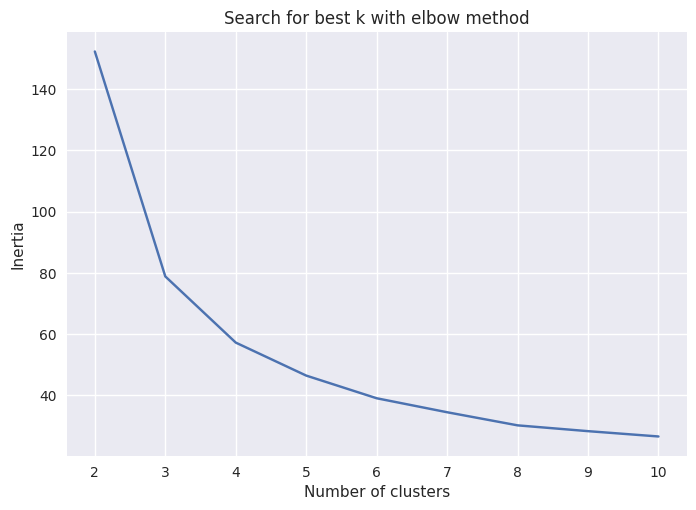

In [ ]:
kmeans_kwargs = {"init":"k-means++", "algorithm":"elkan", "random_state":42}
c.find_clusters_nb('elbow', kmeans_kwargs, 10, kmin=2)
c.plot_metric()

On recherche le 'coude' dans le graphique, c'est à dire la valeur dans le creux entre la partie fortement décroissante et celle a tendance constante. Ici il semble que 3 clusters soit la valeur recherchée

Méthode basée sur le coefficient de silhouette:

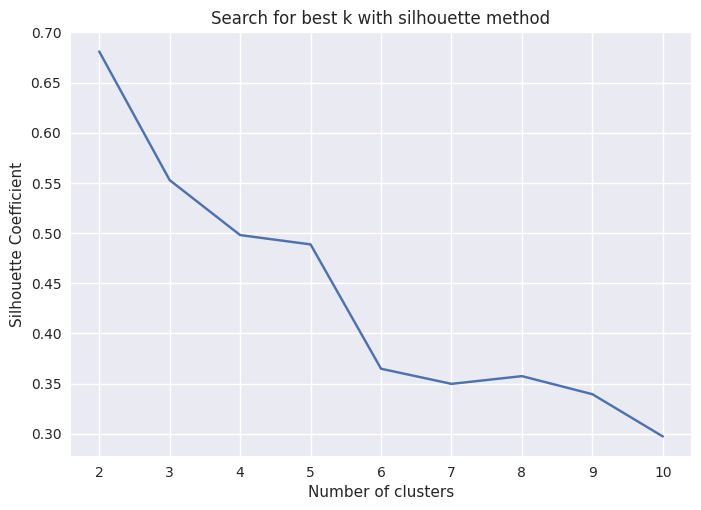

In [ ]:
c.find_clusters_nb('silhouette', kmeans_kwargs, 10, kmin=2)
c.plot_metric()

Ici, un coefficient de silhouette élevé indique des clusters homogènes. On cherche également la première valeur qui fome un 'coude'.
Avec cette méthode on trouve plutôt une valeur de 4 clusters

On ré-entraine alors notre KMeans avec les valeurs apprises lors de l'optimisation avec le GridSearch, mais on change le nombre de clusters à 3:

In [ ]:
optimizer.best_params_

{'algorithm': 'full', 'init': 'k-means++', 'n_clusters': 8}

In [ ]:
kmeans = KMeans(n_clusters=3, algorithm ='full', init='k-means++', random_state = 42)
kmeans.fit(X_train)

KMeans(algorithm='full', n_clusters=3, random_state=42)

In [ ]:
adjusted_mutual_info_score(kmeans.predict(X_test),y_test)

0.8923689116628176

Le score final est un peu meilleur !

### L'algorithme [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

Nous reprenons l'[exemple de sciki-learn](https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py) avec des données simulées:

In [ ]:
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# #############################################################################
# Generate sample data
centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

def dbscan_clusters(X, eps=0.3, min_samples=10):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_

    # Number of clusters in labels, ignoring noise if present.
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)
    print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
    print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
    print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
    print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
    print(
        "Adjusted Mutual Information: %0.3f"
        % metrics.adjusted_mutual_info_score(labels_true, labels)
    )
    print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X, labels))

    # #############################################################################
    # Plot result
    import matplotlib.pyplot as plt

    # Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]

        class_member_mask = labels == k

        xy = X[class_member_mask & core_samples_mask]
        plt.plot(
            xy[:, 0],
            xy[:, 1],
            "o",
            markerfacecolor=tuple(col),
            markeredgecolor="k",
            markersize=14,
        )

        xy = X[class_member_mask & ~core_samples_mask]
        plt.plot(
            xy[:, 0],
            xy[:, 1],
            "o",
            markerfacecolor=tuple(col),
            markeredgecolor="k",
            markersize=6,
        )

    plt.title("Estimated number of clusters: %d" % n_clusters_)
    plt.show()

Estimated number of clusters: 3
Estimated number of noise points: 24
Homogeneity: 0.927
Completeness: 0.845
V-measure: 0.884
Adjusted Rand Index: 0.928
Adjusted Mutual Information: 0.884
Silhouette Coefficient: 0.614


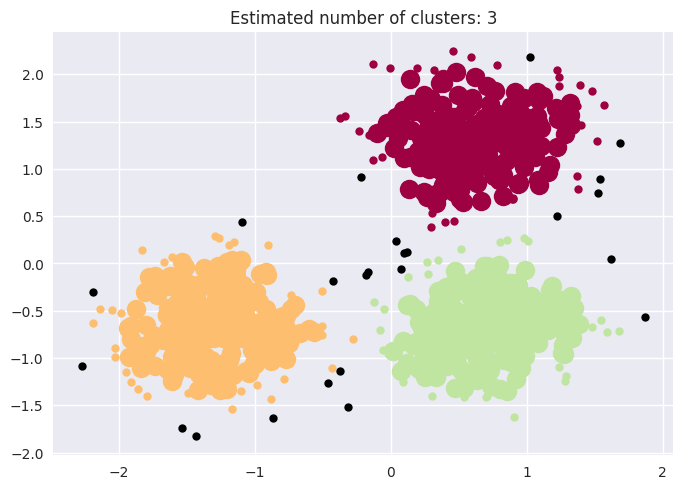

In [ ]:
dbscan_clusters(X, eps=0.35, min_samples=20)

## Pistes d'ameliorations

### Tester d'autres métriques de clustering pour optimiser votre entrainement

Nous avons utlisé la métrique par défaut de KMeans, mais il existe différentes métriques de clustering que vous pouvez tester pour optimiser l'entrainement de votre modèles bien décrites dans la [documentation dédiée de scikit-learn](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation). N'hésitez pas à y faire un tour pour les découvrir avant d'en tester de nouvelles !

### Pour les datasets de grande dimension ($n>10$)

### Utiliser des méthodes de réduction de dimensionalité

Lorsque vous possédez un jeu de données contenant beaucoup de features (vous avez intérêt à **réduire la dimensionalité** de votre dataset en utilisant des méthodes de réduction de dimensionalité, comme par exemple l'[Analyse en Composante Principale](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection) qui va combiner créer des combinaisons linéaires de vos variables initiales. Vous pouvez aussi utiliser des méthodes de **[sélection de features](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)** afin de ne garder dans votre dataset que les **variables les plus informatives**.
L'objectif de ces méthodes est de sélectionner **le modèle le plus parcimonieux**  pour trouver, dans cette tâche, les **clusters les plus généralisables à de nouvelles données**.

### Utiliser des méthodes de plongement

Dans les datasets de grande dimension, il devient difficile de visualiser les données et les clusters que vous avez identifiés. Une approche populaire consiste à utiliser des **projections non-linéaires** comme les **méthodes de plongement** (*[manifold learning](https://scikit-learn.org/stable/modules/manifold.html#manifold-learning))* afin d'apprendre de manière non supervisée, des structures en haute dimension dans les données. Ces méthodes permettent ainsi de créer un espace de plongement, visualisable en 2D, dans lesquels les données peuvent exhiber certaines structures ainsi apprises. Il s'agit d'une **méthode d'exploration pour le clustering** particulièrement intéressante !
Un des algorithme les plus populaires est [t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-distributed-stochastic-neighbor-embedding-t-sne).

### Tester d'autres algorithmes de clustering

Bien entendu, il existe une [grande variété d'algorithmes de clustering](https://scikit-learn.org/stable/modules/clustering.html#clustering) que vous pouvez tester. Je vous conseille cependant de tester les pistes d'améliorations précédantes sur un algorithmes simple (comme ici K-Means) afin de bien appréhender la tache et les données, avant de succomber à la tentation d'utiliser des algorithmes plus complexes

[Guide pratique de clustering avec KMeans](https://realpython.com/k-means-clustering-python/) (et d'autres algorithmes) 

[Example de scikit learn](https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_iris.html#sphx-glr-auto-examples-cluster-plo) sur la visualisation et choix du nombre de clusters sur le jeu de donnée irist-cluster-iris-py

## Quelques tutoriels intéressants